# Exploratory Data Analysis of Olist E-Commerce Dataset

**Internship** : CodeAlpha

**Name**    :  Mehwish Iqbal

**Task**    : 01 EDA

This section focuses on exploring the e-commerce dataset to understand its structure, identify data quality issues, and discover meaningful trends, patterns, and anomalies.

The analysis begins by asking meaningful business questions and examining the variables, data types, missing values, and relationships between datasets. Statistical analysis and visualizations are used to validate assumptions and identify useful business insights.

The main **objectives** of this EDA are to:

* Understand the structure and characteristics of the dataset.
* Identify missing values, duplicates, and other data quality issues.
* Explore trends and patterns in sales, products, customers, orders, delivery, and payments.
* Validate assumptions using statistical analysis and visualization.
* Generate meaningful insights that can support further analysis and business decision-making.

 ---


# 1) Meaningful Business Questions

1. What is the total revenue generated?
2. How does revenue change over time?
3. Which product categories generate the most revenue?
4. What is the average order value?
5. Which states have the highest number of customers?
6. What is the distribution of order statuses?
7. How is delivery performance?
8. What are the most commonly used payment methods?
9. How is revenue distributed across payment methods?

---

In [69]:
# import laibrary
import pandas as pd

In [20]:
# load Datasets of 6 CSV files
orders = pd.read_csv("Downloads/olist_orders_dataset.csv")
order_items = pd.read_csv("Downloads/olist_order_items_dataset.csv.zip")
payments = pd.read_csv("Downloads/olist_order_payments_dataset.csv")
products = pd.read_csv("Downloads/olist_products_dataset.csv")
category_translation = pd.read_csv("Downloads/product_category_name_translation.csv")
customers = pd.read_csv("Downloads/olist_customers_dataset.csv")


# 2) Explore data structure:

In [16]:
# check shape of all datasets

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Category Translation:", category_translation.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)
Category Translation: (71, 2)
Customers: (99441, 5)


In [17]:
# show only 1 dataset 
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
# show all colunms of 6 datasets

print("ORDERS")
print(orders.columns.tolist())

print("\nORDER ITEMS")
print(order_items.columns.tolist())

print("\nPAYMENTS")
print(payments.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

print("\nCATEGORY TRANSLATION")
print(category_translation.columns.tolist())

print("\nCUSTOMERS")
print(customers.columns.tolist())

ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

CATEGORY TRANSLATION
['product_category_name', 'product_category_name_english']

CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [21]:
#check data info 

print("========== ORDERS ==========")
orders.info()

print("\n========== ORDER ITEMS ==========")
order_items.info()

print("\n========== PAYMENTS ==========")
payments.info()

print("\n========== PRODUCTS ==========")
products.info()

print("\n========== CATEGORY TRANSLATION ==========")
category_translation.info()

print("\n========== CUSTOMERS ==========")
customers.info()

========== ORDERS ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

========== ORDER ITEMS ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               -----------

___

# 3) Identify anomalies,data issues or problems

####  a) Missing Values Check

In [22]:
print("========== ORDERS ==========")
print(orders.isnull().sum())

print("\n========== ORDER ITEMS ==========")
print(order_items.isnull().sum())

print("\n========== PAYMENTS ==========")
print(payments.isnull().sum())

print("\n========== PRODUCTS ==========")
print(products.isnull().sum())

print("\n========== CATEGORY TRANSLATION ==========")
print(category_translation.isnull().sum())

print("\n========== CUSTOMERS ==========")
print(customers.isnull().sum())

========== ORDERS ==========
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

========== ORDER ITEMS ==========
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

========== PAYMENTS ==========
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

========== PRODUCTS ==========
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm   

###  b) Duplicate Check

In [23]:
print("========== ORDERS ==========")
print("Duplicate rows:", orders.duplicated().sum())

print("\n========== ORDER ITEMS ==========")
print("Duplicate rows:", order_items.duplicated().sum())

print("\n========== PAYMENTS ==========")
print("Duplicate rows:", payments.duplicated().sum())

print("\n========== PRODUCTS ==========")
print("Duplicate rows:", products.duplicated().sum())

print("\n========== CATEGORY TRANSLATION ==========")
print("Duplicate rows:", category_translation.duplicated().sum())

print("\n========== CUSTOMERS ==========")
print("Duplicate rows:", customers.duplicated().sum())

========== ORDERS ==========
Duplicate rows: 0

========== ORDER ITEMS ==========
Duplicate rows: 0

========== PAYMENTS ==========
Duplicate rows: 0

========== PRODUCTS ==========
Duplicate rows: 0

========== CATEGORY TRANSLATION ==========
Duplicate rows: 0

========== CUSTOMERS ==========
Duplicate rows: 0



 ###  c) Data Type Conversion:


In [24]:
# Orders date columns
order_date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Order items date column
order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'],
    errors='coerce'
)

In [26]:
orders[order_date_cols].dtypes


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [27]:
order_items['shipping_limit_date'].dtype

dtype('<M8[ns]')

Date columns were converted from object/string format  to datetime format to enable accurate time-based analysis

###  d) Categorical values check

In [28]:
print("ORDER STATUS:")
print(orders['order_status'].value_counts())

print("\nPAYMENT TYPE:")
print(payments['payment_type'].value_counts())

print("\nPRODUCT CATEGORIES:")
print(products['product_category_name'].nunique())

ORDER STATUS:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

PAYMENT TYPE:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

PRODUCT CATEGORIES:
73


In [29]:
print("Customer States:", customers['customer_state'].nunique())
print("Customer Cities:", customers['customer_city'].nunique())

Customer States: 27
Customer Cities: 4119


### e) Handlig Missing Values

In [30]:
product_missing = products[
    products['product_category_name'].isnull()
]

print("Rows with missing category:", len(product_missing))

product_missing.isnull().sum()

Rows with missing category: 610


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [31]:
products[products['product_weight_g'].isnull()]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**What we found**

* 610 products have missing product_category/name/description/photo information.
* In those 610 rows, only 1 row has missing physical dimensions/weight.
* The other 1 row (product_id = 5eb...) has all product information missing except product_id

In [32]:
## To check there 610 missing category products are sell in actual order or in product cateloge

ordered_product_ids = order_items['product_id'].unique()

missing_category_sold = products[
    products['product_category_name'].isnull() &
    products['product_id'].isin(ordered_product_ids)
]

print("Missing-category products that were actually ordered:",
      len(missing_category_sold))

Missing-category products that were actually ordered: 610


###  f ) Handle Missing Product Categories

We are replacing missing product categories with **unknown**.

Why:
All 610 products with missing categories were actually used in orders. Removing them could cause loss of important sales data.

In [33]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

**Now merge the product categories with the English translation:**

In [36]:
products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

products['product_category_name_english'] = (
    products['product_category_name_english']
    .fillna('Unknown')
)

### ___Check the result:

In [37]:
print("Unknown categories:",
      (products['product_category_name_english'] == 'Unknown').sum())

Unknown categories: 623




#### Missing Category Handling:

Missing product categories were replaced with "Unknown" instead of removing the records because all 610 products with missing categories were associated with actual orders. This helps preserve important sales data for analysis.



### g ) Check Unknown Categories

In [38]:
unknown_categories = products[
    products['product_category_name_english'] == 'Unknown'
]['product_category_name'].value_counts()

print(unknown_categories)

product_category_name
unknown                                          610
portateis_cozinha_e_preparadores_de_alimentos     10
pc_gamer                                           3
Name: count, dtype: int64


In [39]:
print("Total Unknown product rows:",
      len(products[products['product_category_name_english'] == 'Unknown']))

print("\nUnique Unknown categories:")
print(products[
    products['product_category_name_english'] == 'Unknown'
]['product_category_name'].unique())

Total Unknown product rows: 623

Unique Unknown categories:
['unknown' 'pc_gamer' 'portateis_cozinha_e_preparadores_de_alimentos']


---
**We have:**

* unknown → 610 rows = originally missing categories
* pc_gamer → 3 rows = category exists, but no English translation
* portateis_cozinha_e_preparadores_de_alimentos → 10 rows = category exists, but no English translation

In [40]:
products[products['product_weight_g'].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN,baby
18851,5eb564652db742ff8f28759cd8d2652a,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown


###  h) Handle Missing Physical Measurements
We will keep the missing physical measurements as NaN instead of filling them with artificial values.

In [41]:
# Keep missing physical measurements as NaN
# No imputation is required because these fields are not needed
# for the planned EDA analysis.

print("Missing physical measurements:")
print(products[['product_weight_g',
                'product_length_cm',
                'product_height_cm',
                'product_width_cm']].isnull().sum())

Missing physical measurements:
product_weight_g     2
product_length_cm    2
product_height_cm    2
product_width_cm     2
dtype: int64


**Missing Physical Measurements:**

Two product records contain missing physical measurements such as weight and dimensions. These values were not imputed because they are not required for the planned sales, customer, category, payment, and delivery analysis. The missing values were retained as NaN to avoid introducing artificial data.

### i ) Check Dataset Relationships

In [42]:
print("Orders:", orders['order_id'].nunique())
print("Customers:", customers['customer_id'].nunique())
print("Products:", products['product_id'].nunique())

print("\nOrder items with missing order IDs:",
      (~order_items['order_id'].isin(orders['order_id'])).sum())

print("Order items with missing product IDs:",
      (~order_items['product_id'].isin(products['product_id'])).sum())

print("Orders with missing customer IDs:",
      (~orders['customer_id'].isin(customers['customer_id'])).sum())

Orders: 99441
Customers: 99441
Products: 32951

Order items with missing order IDs: 0
Order items with missing product IDs: 0
Orders with missing customer IDs: 0


 **Dataset Relationship Check:**

Key identifiers were checked before merging the datasets to ensure that 
orders, customers, products, and order items could be reliably connected for further analysis.

# Create Main E-Commerce Dataset

Now, we will merge order_items, products, orders, and customers to create the main analysis dataset.

**Important:** We will not merge payments directly at this stage because a single order can have multiple payment records. Merging it directly could create duplicate rows and affect our analysis.

In [46]:
sales_data = order_items.merge(
    products[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
).merge(
    orders[['order_id',
            'customer_id',
            'order_status',
            'order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_estimated_delivery_date']],
    on='order_id',
    how='left'
).merge(
    customers[['customer_id',
               'customer_unique_id',
               'customer_city',
               'customer_state']],
    on='customer_id',
    how='left'
)

print("Sales dataset shape:", sales_data.shape)
sales_data.head()

Sales dataset shape: (112650, 16)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP


**Main Dataset Creation:**

The order items, product, order, and customer datasets were merged using their respective identifiers. The resulting dataset combines product, sales, order, delivery, and customer information for further e-commerce analysis.

___

# 4) Identify trends & patterns

  **solving there Business Questions**

1. What is the total revenue generated?
2. How does revenue change over time?
3. Which product categories generate the most revenue?
4. What is the average order value?
5. Which states have the highest number of customers?
6. What is the distribution of order statuses?
7. How is delivery performance?
8. What are the most commonly used payment methods?
9. How is revenue distributed across payment methods?

## 1. What is the Total Revenue Generated?

### Total Sales Revenue

To understand the overall sales performance, we calculate the total revenue generated from product sales.

The `price` column represents the product price, while `freight_value` represents shipping charges. Therefore, product sales revenue is calculated using the `price` column.

In [47]:
total_revenue = sales_data['price'].sum()

print(f"Total Sales Revenue: ${total_revenue:,.2f}")

Total Sales Revenue: $13,591,643.70


### Business Insight

The total product sales revenue generated across all order items is **$13.59 million**. This provides a baseline measure of the overall sales volume in the dataset and can be used to evaluate revenue trends and category performance in the following analysis.

---

## 2. How Does Revenue Change Over Time?

### Monthly Revenue Trend

To understand how sales performance changes over time, monthly revenue is calculated using the order purchase date.

This analysis helps identify growth trends, seasonal patterns, and periods with higher or lower sales.

In [71]:
# Create a monthly period from the order purchase date
sales_data['purchase_month'] = (
    sales_data['order_purchase_timestamp']
    .dt.to_period('M')
)

# Calculate monthly revenue
monthly_revenue = (
    sales_data.groupby('purchase_month')['price']
    .sum()
    .reset_index()
)

monthly_revenue.head(15)

,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


### by line chart 

The monthly revenue trend is visualized to identify changes in sales performance over time and highlight periods of higher or lower revenue.

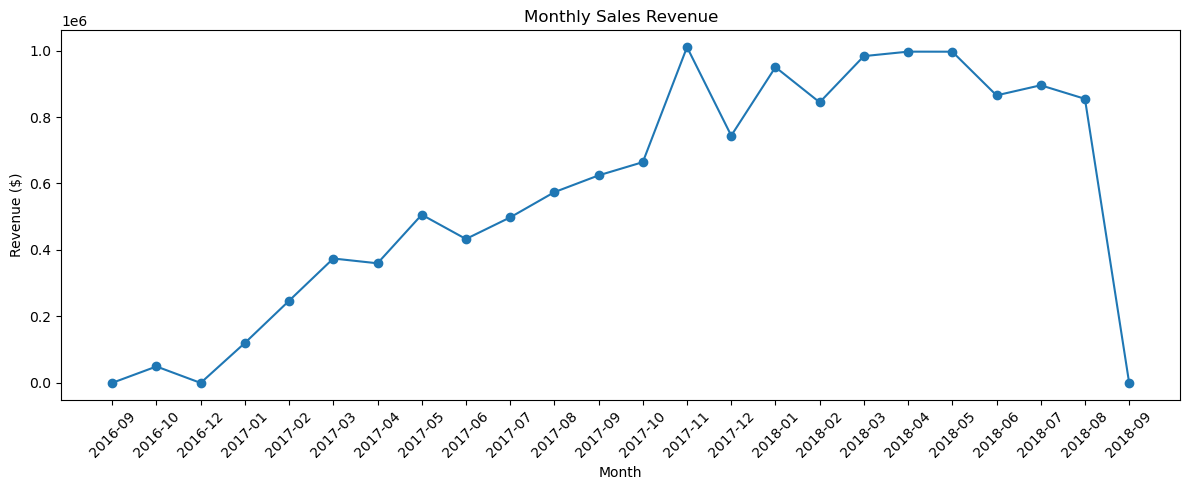

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue['purchase_month'].astype(str),
    monthly_revenue['price'],
    marker='o'
)

plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**insight**

* Sales revenue generally increased over time.
* Revenue peaked around Nov 2017 (~$1.01M).
* Revenue remained high during 2018, with a decline toward the final month.


 ---

## 3. Which Product Categories Generate the Most Revenue
### Revenue by Product Category

To identify the best-performing product categories, we calculate the total sales revenue generated by each product category.

This analysis helps determine which categories contribute the most to overall sales.

In [50]:
category_revenue = (
    sales_data.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head(10)

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


**Insight:**

* Health & Beauty had the highest revenue at $1.26M,

* while  Garden Tools  had the lowest at $485K
among the top 10 categories.


---

## 4. What is the Average Order Value?

### Average Order Value (AOV)

Average Order Value (AOV) measures the average amount spent per order.

It is calculated by dividing the total product sales revenue by the total number of unique orders.

In [51]:
total_orders = sales_data['order_id'].nunique()

average_order_value = (
    sales_data['price'].sum() / total_orders
)

print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Orders: 98,666
Average Order Value: $137.75


---

## 5. Which States Have the Highest Number of Customers?
### Customers by State

To understand the geographical distribution of customers, we analyze the number of unique customers in each state.

This helps identify the states with the largest customer base.

In [52]:
state_customers = (
    sales_data.groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

state_customers.head(10)

,customer_state,customer_unique_id
0,SP,39981
1,RJ,12303
2,MG,11178
3,RS,5249
4,PR,4840
5,SC,3513
6,BA,3257
7,DF,2062
8,ES,1956
9,GO,1942


 ### by graph

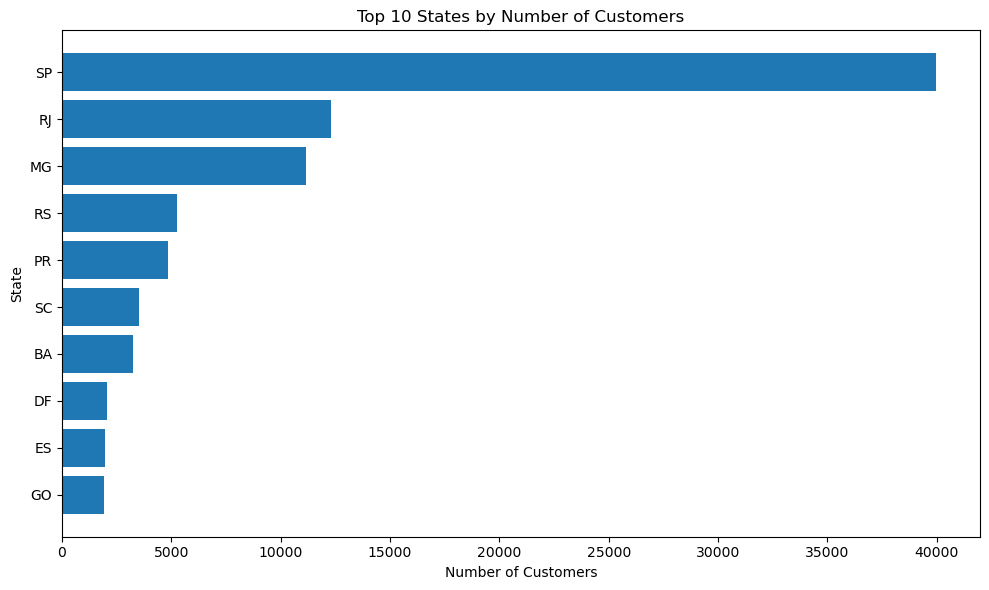

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_customers.head(10)['customer_state'][::-1],
    state_customers.head(10)['customer_unique_id'][::-1]
)

plt.title('Top 10 States by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('State')
plt.tight_layout()
plt.show()

**Insight:** 

São Paulo (SP) had the highest number of customers (39,981), followed by RJ (12,303) and MG (11,178).

---

## 6. What Is the Distribution of Order Statuses?

### Order Status Distribution

To understand the overall order lifecycle, we analyze the distribution of different order statuses.

This helps identify how many orders were delivered, shipped, canceled, unavailable, or in other stages of processing.

In [58]:
# code
order_status_counts = (
    orders['order_status']
    .value_counts()
    .reset_index()
)

order_status_counts.columns = ['order_status', 'order_count']

order_status_counts


,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


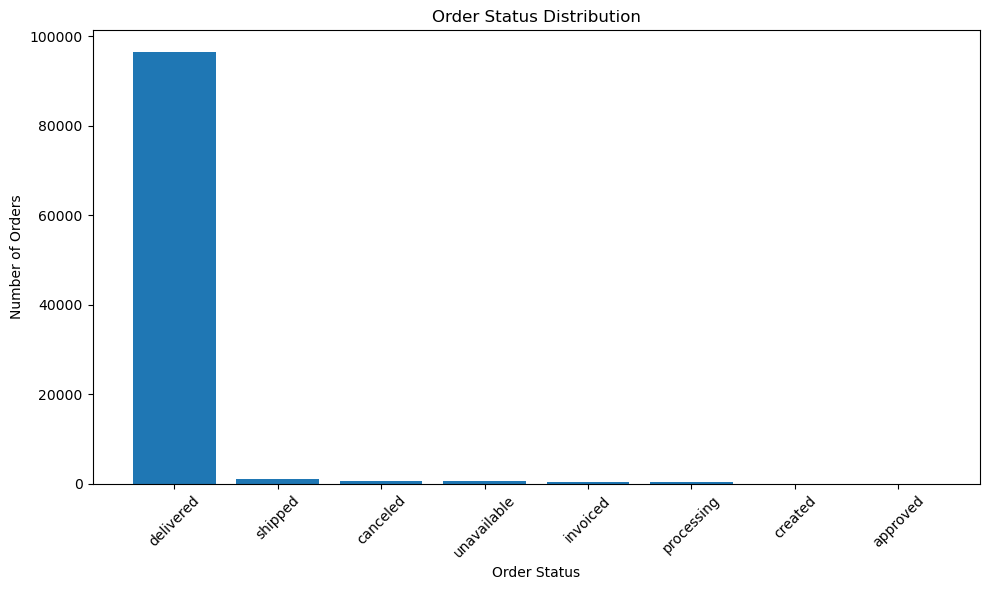

In [73]:
plt.figure(figsize=(10, 6))

plt.bar(
    order_status_counts['order_status'],
    order_status_counts['order_count']
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** 

Most orders were delivered (96,478), showing a high delivery completion rate. Only 625 orders were canceled.

---

## 7. How Is Delivery Performance?

### Delivery Performance

To evaluate delivery performance, the actual delivery date is compared with the estimated delivery date.

A delivery is considered on time when the actual delivery date is on or before the estimated delivery date. A delivery is considered late when the actual delivery date is after the estimated delivery date.

### Step 1 — Calculate Delivery Days

In [54]:
# Calculate the number of days taken to deliver each order
sales_data['delivery_days'] = (
    sales_data['order_delivered_customer_date']
    - sales_data['order_purchase_timestamp']
).dt.days

sales_data[['order_id', 'delivery_days']].head()

,order_id,delivery_days
0,00010242fe8c5a6d1ba2dd792cb16214,7.0
1,00018f77f2f0320c557190d7a144bdd3,16.0
2,000229ec398224ef6ca0657da4fc703e,7.0
3,00024acbcdf0a6daa1e931b038114c75,6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,25.0


### Step 2 — Calculate Delay

In [55]:
# Calculate the difference between actual and estimated delivery dates
sales_data['delivery_delay_days'] = (
    sales_data['order_delivered_customer_date']
    - sales_data['order_estimated_delivery_date']
).dt.days

sales_data[['order_id', 'delivery_delay_days']].head()

,order_id,delivery_delay_days
0,00010242fe8c5a6d1ba2dd792cb16214,-9.0
1,00018f77f2f0320c557190d7a144bdd3,-3.0
2,000229ec398224ef6ca0657da4fc703e,-14.0
3,00024acbcdf0a6daa1e931b038114c75,-6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,-16.0


## step 3 ___ On-Time vs Late Delivery

### On-Time vs Late Deliveries

To evaluate delivery reliability, orders are classified as on-time or late based on the difference between the actual and estimated delivery dates.

Orders delivered on or before the estimated date are classified as "On Time", while orders delivered after the estimated date are classified as "Late".

In [60]:
# Classify deliveries as On Time or Late
sales_data['delivery_performance'] = sales_data['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

delivery_performance = (
    sales_data['delivery_performance']
    .value_counts()
    .reset_index()
)

delivery_performance.columns = ['delivery_performance', 'order_count']

delivery_performance

,delivery_performance,order_count
0,On Time,105385
1,Late,7265


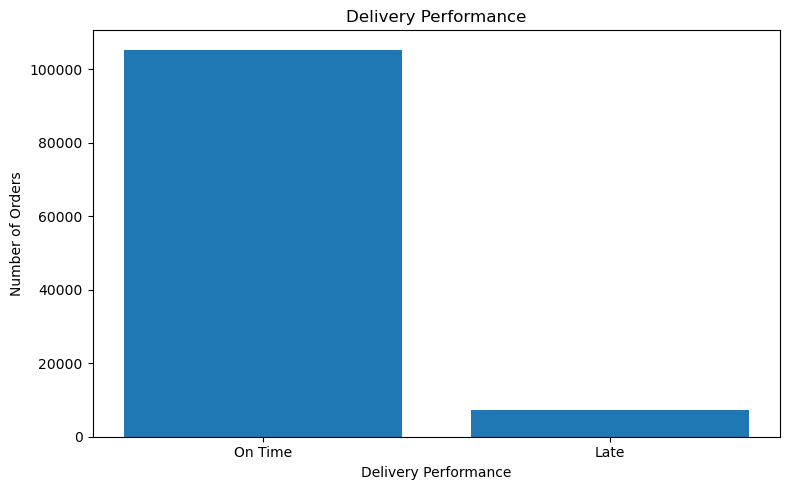

In [61]:
# chart

plt.figure(figsize=(8, 5))

plt.bar(
    delivery_performance['delivery_performance'],
    delivery_performance['order_count']
)

plt.title('Delivery Performance')
plt.xlabel('Delivery Performance')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Insight**
* Most orders were delivered on time (105,385).
* Only 7,265 orders were late, so graph showing strong delivery performance.

---

## 8. What Are the Most Commonly Used Payment Methods?

### Payment Method Distribution

To understand customer payment preferences, we analyze the number of transactions made using each payment method.

This analysis helps identify the most commonly used payment methods among customers.

**Important:** Here, I using the original `payments` dataset instead of `sales_data` because a single order can have multiple payment records. Using `sales_data` could lead to duplicate payment records and affect the analysis.

In [62]:
payment_method_counts = (
    payments['payment_type']
    .value_counts()
    .reset_index()
)

payment_method_counts.columns = ['payment_type', 'transaction_count']

payment_method_counts

,payment_type,transaction_count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


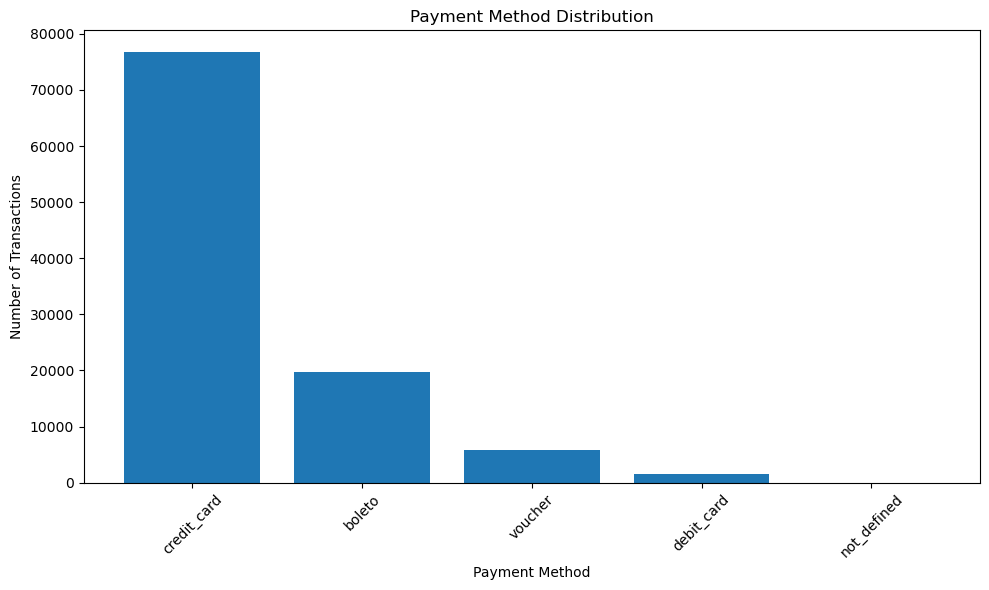

In [63]:
# chart

plt.figure(figsize=(10, 6))

plt.bar(
    payment_method_counts['payment_type'],
    payment_method_counts['transaction_count']
)

plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**

Credit cards were the most used payment method (76,795 transactions), while debit cards had the lowest usage (1,529).

## 9. How Is Revenue Distributed Across Payment Methods?
### Payment Value by Payment Method

To understand how customer payments are distributed across different payment methods, we calculate the total payment value associated with each payment type.

Here, payment_value represents the amount paid through each payment method


**Important:** Here, we are using the original `payments` dataset instead of `sales_data` because a single order can have multiple payment records. Using `sales_data` could lead to duplicate payment records and affect the analysis.

In [64]:
payment_revenue = (
    payments.groupby('payment_type')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

payment_revenue

,payment_type,payment_value
0,credit_card,12542084.19
1,boleto,2869361.27
2,voucher,379436.87
3,debit_card,217989.79
4,not_defined,0.00


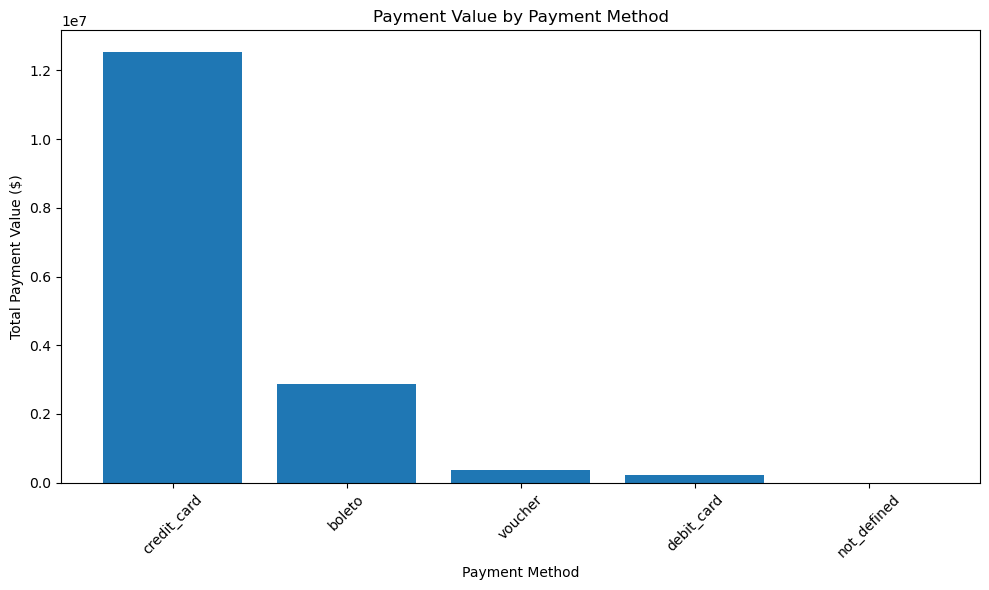

In [75]:
plt.figure(figsize=(10, 6))

plt.bar(
    payment_revenue['payment_type'],
    payment_revenue['payment_value']
)

plt.title('Payment Value by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Payment Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**

Credit cards generated the highest payment value ($12.54M), far exceeding all other payment methods.

----

# 5) Hypothesis Testing / Assumption Validation

### a)  Hypothesis: Delivery Performance

**Assumption:** Most orders are delivered on time.

**Null Hypothesis  (H0)**: The proportion of on time and late deliveries is equal (no significant difference).

**Alternative Hypothesis (H1)** : The proportion of on time deliverie is heghier than  late deliveries.

In [76]:
delivery_data = orders[
    ['order_id',
     'order_delivered_customer_date',
     'order_estimated_delivery_date']
].copy()

delivery_data['delivery_delay_days'] = (
    delivery_data['order_delivered_customer_date']
    - delivery_data['order_estimated_delivery_date']
).dt.days

delivery_data['delivery_performance'] = delivery_data[
    'delivery_delay_days'
].apply(
    lambda x: 'Late' if x > 0
    else ('On Time' if pd.notna(x) else 'Not Delivered')
)

delivery_summary = (
    delivery_data['delivery_performance']
    .value_counts()
    .reset_index()
)

delivery_summary.columns = [
    'delivery_performance',
    'order_count'
]

delivery_summary

,delivery_performance,order_count
0,On Time,89941
1,Late,6535
2,Not Delivered,2965


### b) Descriptive statistics: 
Amoung delivered order (exclusive not delivered ) the majoriey were delivered on time . 

'Count + percentage'

In [79]:


delivered_orders = delivery_data[
    delivery_data['delivery_performance'].isin(['On Time', 'Late'])
].copy()

delivery_summary = (
    delivered_orders['delivery_performance']
    .value_counts()
    .reset_index()
)

delivery_summary.columns = [
    'delivery_performance',
    'order_count'
]

delivery_summary['percentage'] = (
    delivery_summary['order_count']
    / delivery_summary['order_count'].sum()
    * 100
)

delivery_summary

,delivery_performance,order_count,percentage
0,On Time,89941,93.226295
1,Late,6535,6.773705


### c ) Visulization 

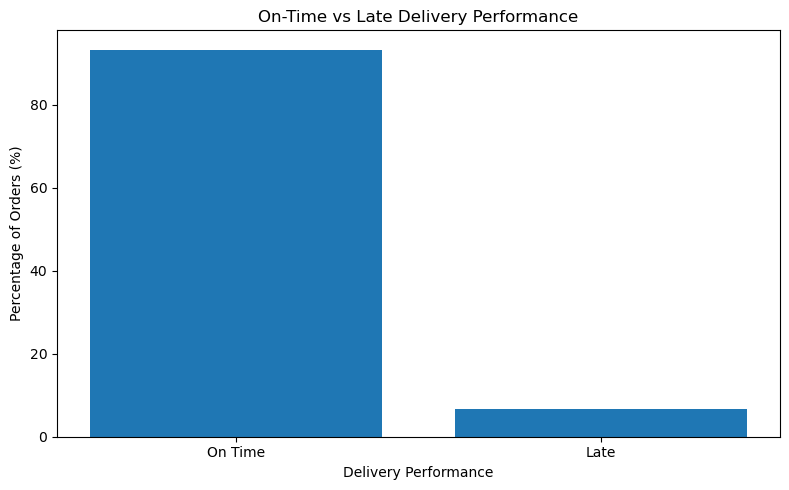

In [82]:
delivery_summary_filtered = delivery_summary[
    delivery_summary['delivery_performance'].isin(['On Time', 'Late'])
]

plt.figure(figsize=(8, 5))

plt.bar(
    delivery_summary_filtered['delivery_performance'],
    delivery_summary_filtered['percentage']
)

plt.title('On-Time vs Late Delivery Performance')
plt.xlabel('Delivery Performance')
plt.ylabel('Percentage of Orders (%)')
plt.tight_layout()
plt.show()

### d) Chi_Square Test:
 
 To test whether the distribution of on time and late deliveries is sighnificanly is different a chi_square Goodness of fit test was performed.  

In [80]:
from scipy.stats import chisquare

observed = [
    89941,  # On Time
    6535    # Late
]

expected = [
    (89941 + 6535) / 2,
    (89941 + 6535) / 2
]

chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Chi-square statistic: 72106.64658567934
p-value: 0.0


In [81]:
if p_value < 0.05:
    print("The result is statistically significant.")
else:
    print("The result is not statistically significant.")

The result is statistically significant.


### d) Hypothesis supported
* The hypothesis showes that **93.24%** deliveries are delivered on time , while **6.76** were late .
* the chi_square test result (**p_value = 0.0**)  indicates atatisticaly  sighnificant  difference  in the delivery performance distribution

There' for the assumption that  most orders are delivered on time is supported on data.

---

## Key EDA Insights / Findings

The exploratory analysis revealed several important findings:

* The dataset represents a large-scale e-commerce operation with approximately $13.59 million in product sales revenue.

* Health & Beauty, Watches & Gifts, and Bed, Bath & Table were among the leading revenue-generating product categories.
* The average order value was approximately $137.75.
* São Paulo had the largest customer base among Brazilian states.
* Most orders were successfully delivered.
* Credit cards were the dominant payment method by both usage and overall payment value.
* Most analyzed deliveries were classified as On Time, although late and undelivered orders were also present.
* The statistical analysis indicated a significant relationship between the categorical variables tested in the Chi-Square analysis.


## Conclusion

The Exploratory Data Analysis provided an overall understanding of the Olist e-commerce dataset, including sales, customers, products, orders, payments, and delivery performance. The analysis identified important patterns in revenue, customer distribution, payment behavior, and order activity, providing a strong foundation for further analysis.

## Future Analysis and Recommendations

* Visualize monthly and seasonal sales trends.
* Compare product category performance.
* Explore customer distribution across regions.
* Analyze payment methods and order activity patterns.
* Examine the relationship between product price and freight value.
* Visualize delivery differences across product categories.
* Explore customer reviews through sentiment analysis.
* Develop interactive dashboards for deeper business insights.
